### **Customer Churn Analysis**

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

The objective of this project is to analyze the customer data and find the reasons why the customer is leaving the company’s service. This project aims to find the important factors affecting the customer churn like contract type, payment method, customer satisfaction, and service usage to give valuable business insights and advice.


### Project Objective
- Calculate overall churn rate
- Identify key factors influencing customer churn
- Analyze customer demographics and service usage patterns
- Identify major churn reasons
- Build visualizations and dashboards
- Provide business recommendations to reduce churn


### Dataset Overview

This dataset contains customer demographic information, services subscribed, contract details, payment methods, charges, satisfaction score, and churn information. The dataset includes 7,043 customers and multiple factors related to customer behavior and service usage. The target variable for this analysis is the Churn label, Which indicates whether the customer has churned or not. 

In [9]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


### Data Loading and Understanding
 
 In this section, we load the dataset and explore the structure of the data, including column names, data types, and summary statistics.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/telco.csv')

df.head()

df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

### Overall Churn Rate and KPI Metrics

In this section, we calculate key performance indicators such as total customers, churned cutomers, churn rate, average monthly charge, and average tenure to understand overall business performance.

In [5]:
#Create Churn_Flag

df['Churn_Flag'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
df['Churn_Flag'].value_counts()


# Basic KPI Metrics

total_customers = df.shape[0]
churned_customers = df['Churn_Flag'].sum()
retained_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers * 100
avg_monthly_charge = df['Monthly Charge'].mean()
avg_tenure = df['Tenure in Months'].mean()
total_revenue = df['Total Revenue'].sum()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", churn_rate)
print("Average Monthly Charge:", avg_monthly_charge)
print("Average Tenure:", avg_tenure)
print("Total Revenue:", total_revenue)





Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.536987079369588
Average Monthly Charge: 64.76169246059918
Average Tenure: 32.38676700269772
Total Revenue: 21371131.689999998


### 1. Churn rate by contract

In [6]:
df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False) * 100

Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Churn_Flag, dtype: float64

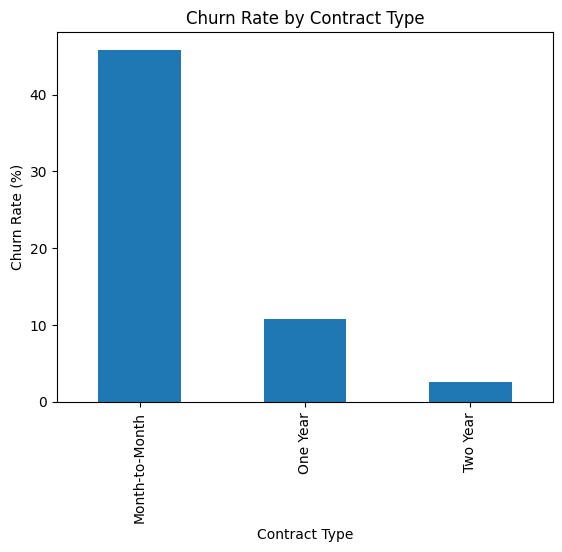

<Figure size 640x480 with 0 Axes>

In [7]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False) * 100

contract_churn.plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.show()

plt.savefig('../images/churn_contract.png', bbox_inches='tight')

### 2. Churn rate by Payment method

In [ ]:
df.groupby('Payment Method')['Churn_Flag'].mean().sort_values(ascending=False) * 100

Payment Method
Mailed Check       36.883117
Bank Withdrawal    33.998465
Credit Card        14.477992
Name: Churn_Flag, dtype: float64

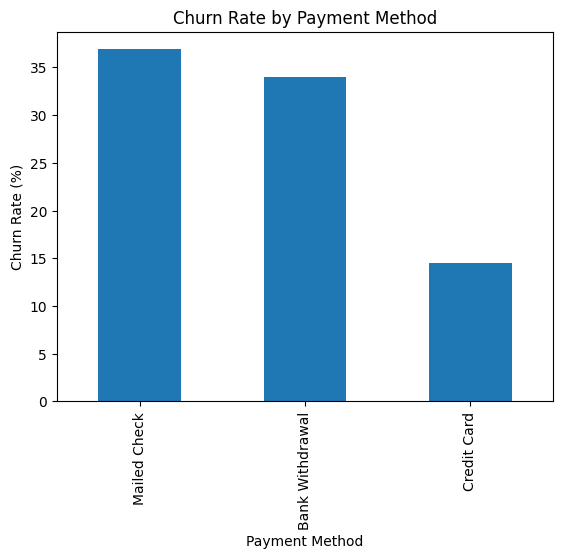

In [59]:
payment_churn = df.groupby('Payment Method')['Churn_Flag'].mean().sort_values(ascending=False) * 100

payment_churn.plot(kind='bar')
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.show()

### 3. Churn rate by Internet Service 

In [ ]:


df.groupby('Internet Service')['Churn_Flag'].mean().sort_values(ascending=False) * 100

Internet Service
Yes    31.828893
No      7.404980
Name: Churn_Flag, dtype: float64

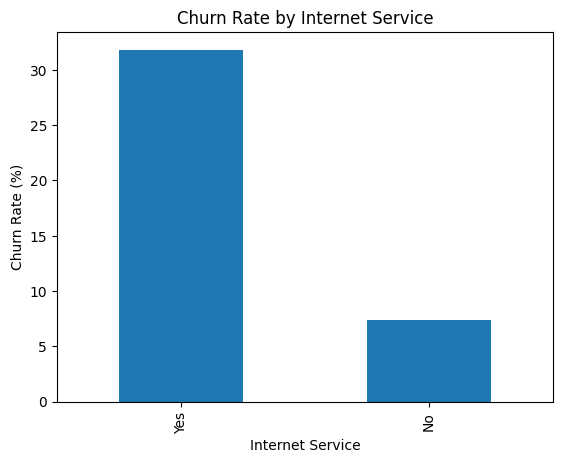

In [61]:
internet_churn = df.groupby('Internet Service')['Churn_Flag'].mean().sort_values(ascending=False) * 100

internet_churn.plot(kind='bar')
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")
plt.show()

### 4. Churn rate by Senior Citizens

In [ ]:
df.groupby('Senior Citizen')['Churn_Flag'].mean() * 100

Senior Citizen
No     23.606168
Yes    41.681261
Name: Churn_Flag, dtype: float64

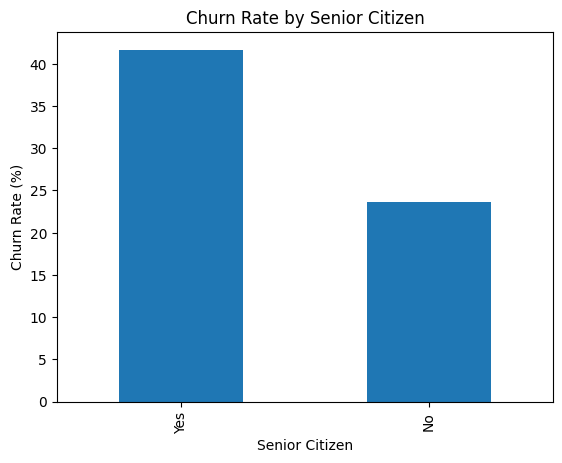

In [63]:
senior_churn = df.groupby('Senior Citizen')['Churn_Flag'].mean().sort_values(ascending=False) * 100

senior_churn.plot(kind='bar')
plt.title("Churn Rate by Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Senior Citizen")
plt.show()

### 5. Churn rate by Married

In [ ]:

df.groupby('Married')['Churn_Flag'].mean() * 100

Married
No     32.957979
Yes    19.664903
Name: Churn_Flag, dtype: float64

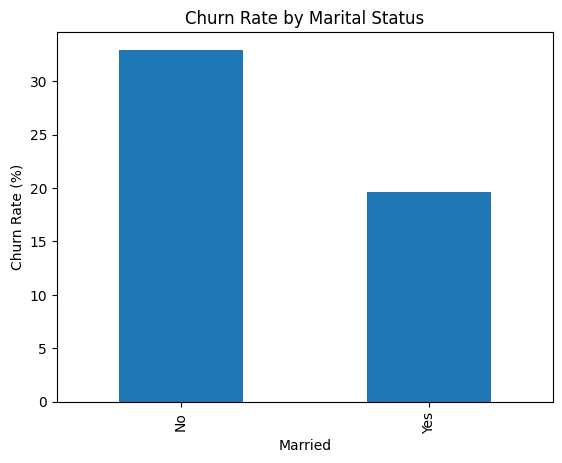

In [65]:
married_churn = df.groupby('Married')['Churn_Flag'].mean() * 100

married_churn.plot(kind='bar')
plt.title("Churn Rate by Marital Status")
plt.ylabel("Churn Rate (%)")
plt.show()

### 6. Churn rate by Dependents

In [ ]:


df.groupby('Dependents')['Churn_Flag'].mean() * 100

Dependents
No     32.551699
Yes     6.515058
Name: Churn_Flag, dtype: float64

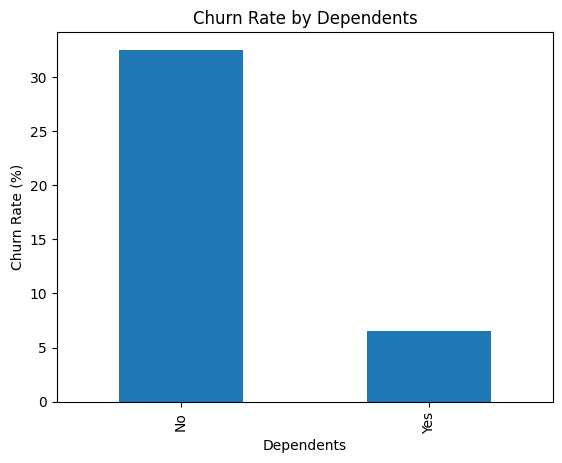

In [67]:
dependents_churn = df.groupby('Dependents')['Churn_Flag'].mean() * 100

dependents_churn.plot(kind='bar')
plt.title("Churn Rate by Dependents")
plt.ylabel("Churn Rate (%)")
plt.show()

### 7. Churn rate by Satisfaction Score

In [ ]:

df.groupby('Satisfaction Score')['Churn_Flag'].mean().sort_values(ascending=False) * 100


Satisfaction Score
1    100.000000
2    100.000000
3     16.097561
4      0.000000
5      0.000000
Name: Churn_Flag, dtype: float64

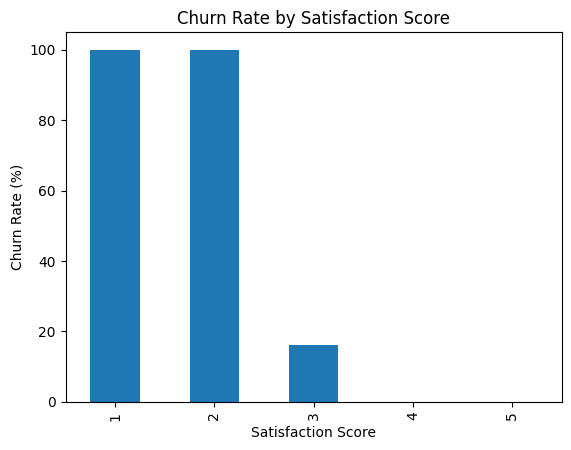

In [69]:
sat_churn = df.groupby('Satisfaction Score')['Churn_Flag'].mean() * 100

sat_churn.plot(kind='bar')
plt.title("Churn Rate by Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.show()

In [73]:
total_customers = df.shape[0]
churned_customers = df['Churn_Flag'].sum()

churn_rate = churned_customers / total_customers * 100
print(churn_rate)

26.536987079369588


## Exploratory Data Analysis
In this section, customer churn is analyzed across different customer segments such as contract type, payment method, internet service, demographics, and satisfaction score.

### Churn by Contract

In [30]:
df.groupby('Contract')['Churn_Flag'].mean() * 100

Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Churn_Flag, dtype: float64

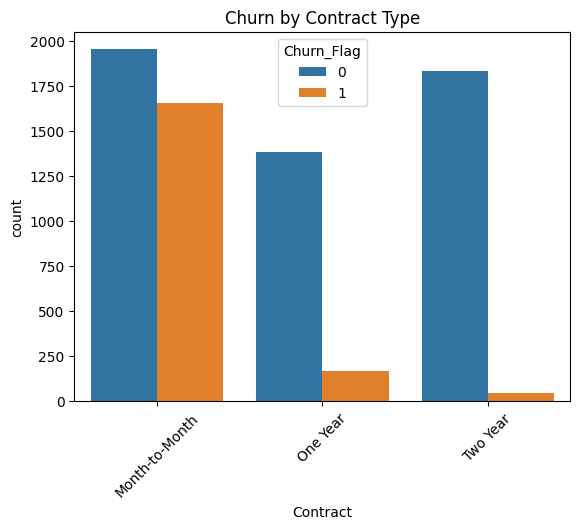

In [32]:
sns.countplot(data=df, x='Contract', hue='Churn_Flag')
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

Customers with month-to-month contracts have the highest churn rate, while one-year and two-year contract customers are more likely to stay.

### Churn by Payment Method

In [34]:
df.groupby('Payment Method')['Churn_Flag'].mean() * 100

Payment Method
Bank Withdrawal    33.998465
Credit Card        14.477992
Mailed Check       36.883117
Name: Churn_Flag, dtype: float64

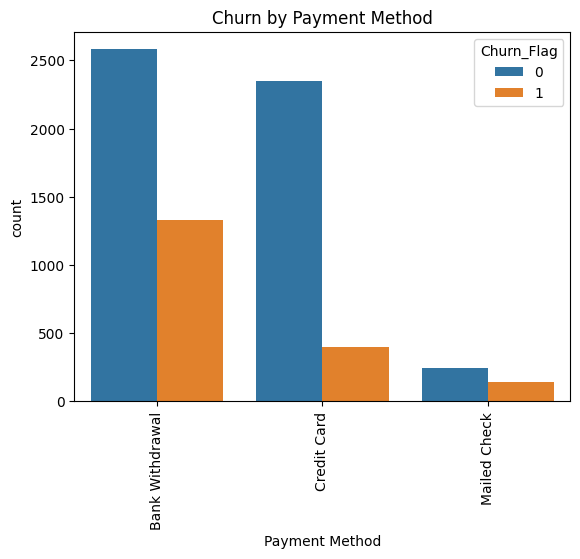

In [36]:
sns.countplot(data=df, x='Payment Method', hue='Churn_Flag')
plt.title("Churn by Payment Method")
plt.xticks(rotation=90)
plt.show()

Customers using mailed check and bank withdrawal show higher churn compared to credit card users.

### Churn by Internet Service

In [37]:
df.groupby('Internet Service')['Churn_Flag'].mean() * 100

Internet Service
No      7.404980
Yes    31.828893
Name: Churn_Flag, dtype: float64

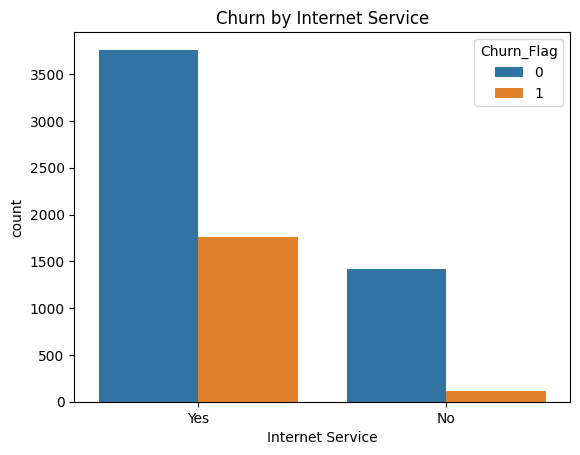

In [38]:
sns.countplot(data=df, x='Internet Service', hue='Churn_Flag')
plt.title("Churn by Internet Service")
plt.show()

Customers with internet service have a much higher churn rate than customers without internet service.

### Churn by Senior Citizen


In [39]:
df.groupby('Senior Citizen')['Churn_Flag'].mean() * 100

Senior Citizen
No     23.606168
Yes    41.681261
Name: Churn_Flag, dtype: float64

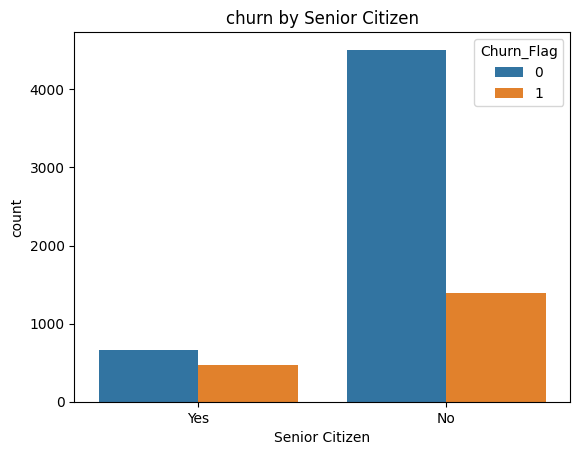

In [ ]:
sns.countplot(data=df, x='Senior Citizen', hue='Churn_Flag')
plt.title("Churn by Senior Citizen")
plt.show()

Senior citizen customers have a significantly higher churn rate than non-senior customers.

### Churn by Marital Status


In [41]:
df.groupby('Married')['Churn_Flag'].mean() * 100

Married
No     32.957979
Yes    19.664903
Name: Churn_Flag, dtype: float64

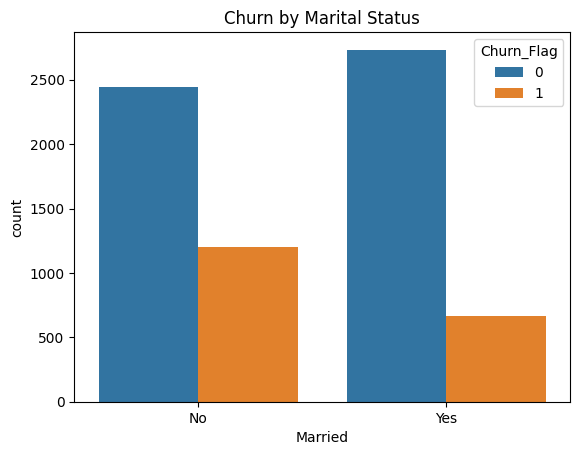

In [42]:
sns.countplot(data=df, x='Married', hue='Churn_Flag')
plt.title("Churn by Marital Status")
plt.show()

Customers who are not married have a higher churn rate than married customers.

### Churn by Dependents

In [43]:
df.groupby('Dependents')['Churn_Flag'].mean() * 100


Dependents
No     32.551699
Yes     6.515058
Name: Churn_Flag, dtype: float64

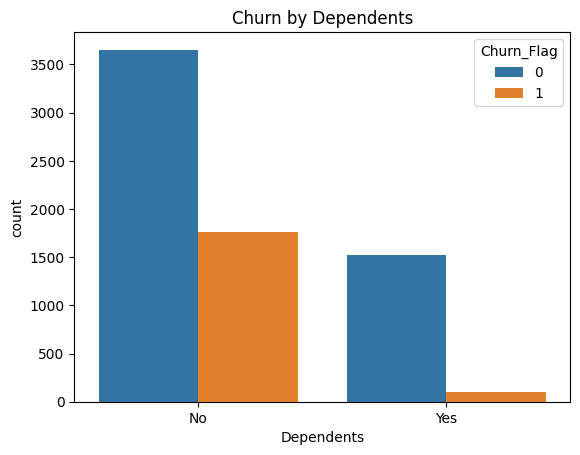

In [44]:
sns.countplot(data=df, x='Dependents', hue='Churn_Flag')
plt.title("Churn by Dependents")
plt.show()

Customers without dependents have a much higher churn rate compared to customers with dependents.

### Satisfaction Score vs Churn

In [45]:
df.groupby('Satisfaction Score')['Churn_Flag'].mean() * 100

Satisfaction Score
1    100.000000
2    100.000000
3     16.097561
4      0.000000
5      0.000000
Name: Churn_Flag, dtype: float64

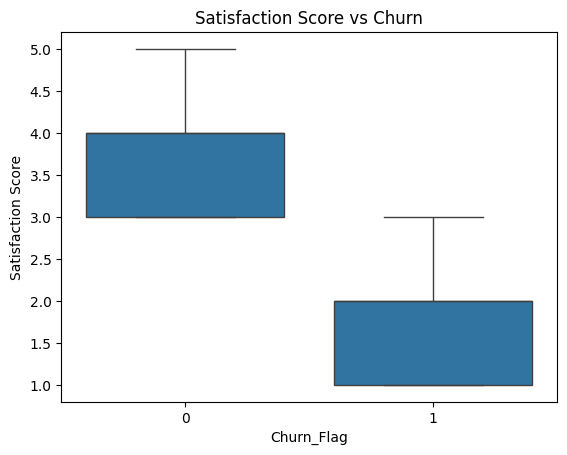

In [47]:
sns.boxplot(data=df, x='Churn_Flag', y='Satisfaction Score')
plt.title("Satisfaction Score vs Churn")
plt.show()

Low Satisfaction scores are strongly associated with churn, showing that customer experience is a major driver of retention.

### Monthly Charge vs Churn

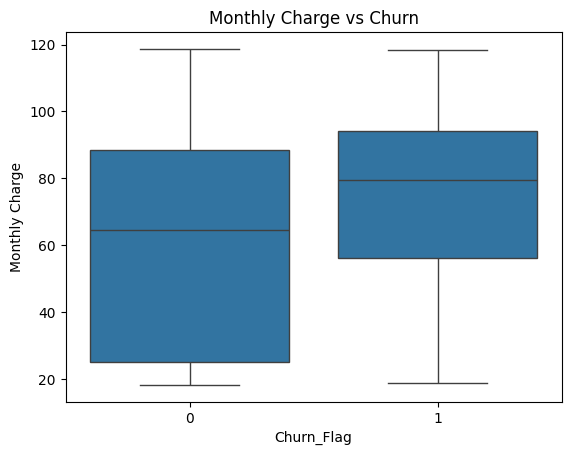

In [48]:
sns.boxplot(data=df, x='Churn_Flag', y='Monthly Charge')
plt.title("Monthly Charge vs Churn")
plt.show()

Customers with higher monthly charges tend to show higher churn risk.

### Tenure vs Churn

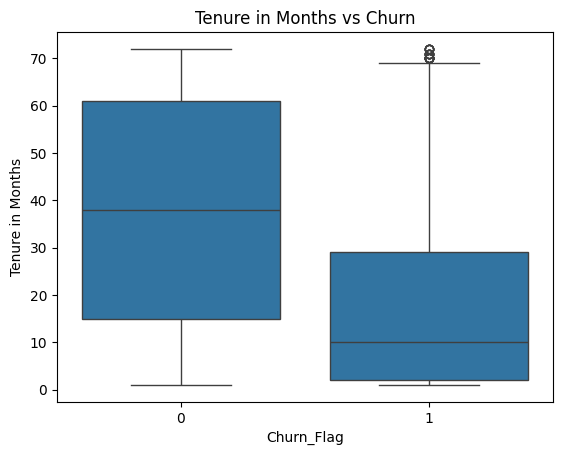

In [49]:
sns.boxplot(data=df, x='Churn_Flag', y='Tenure in Months')
plt.title("Tenure in Months vs Churn")
plt.show()

Customers with shorter tenure are significantly more likely to churn, indicating that new customers are at higher risk of leaving the service.

### Churn Reasons Analysis


In [51]:
df[df['Churn_Flag'] == 1]['Churn Category'].value_counts()

Churn Category
Competitor         841
Attitude           314
Dissatisfaction    303
Price              211
Other              200
Name: count, dtype: int64

In [52]:
df[df['Churn_Flag'] == 1]['Churn Reason'].value_counts().head(10)

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64

## Key Insights 

- The overall churn rate is **26.54%**, indicating a significant customer retention issue.
- Customers with **month-to-month contracts** have the highest churn rate compared to long-term contracts.
- Customers with **mailed check and bank withdrawal** payment methods show higher churn compares to credit card users.
- Customers with **internet service** have a higher churn rate than those without internet service.
- **Senior citizen customers** have significantly higher churn rates.
- Customers who are **not married** have higher churn rates compared to married customers.
- Customers **Without dependents** show much highers churn behaviour.
- Customers with **low satisfaction scores (1 and 2)** are highly likely to churn.
- Customers with **short tenure** are more likely to churn than long-term customers.
- The main churn reasons include **competitor pricing, customer service issues, and service dissatisfaction**.

## Business Recommendations

- Encourage customers to switch from **month-to-month contracts to long-term contracts** through discounts and incentives.
- Promote **automatic payment methods** such as credit cards to reduce churn risk.
- Improve **internet service quality and reliability** to retain customers.
- Provide better **customer support and simplified plans for senior citizens**.
- Create **targeted retention programs** for customers who are not married and do not have dependents.
- MOnitor customers with **low satisfaction scores** and take protective actions to retain them.
- Offer **loyalty rewards and discounts** for long-term customers.
- Improve **pricing strategies** to compete with competitors.
- Address key churn reasons such as **customer service issues and network reliability**.


## Project Summary

1. Total Customers: 7,043
2. Churn Rate: 26.54%
3. Highest Risk Group: Month-to-Month Contract Customers
4. Key Driver: Low Customer Satisfaction
5. Top Churn Reason: Competitor and Service Issues

## Conclusion

This project analyzed customer churn behavior using demographic, service usage, and customer satisfaction data. The analysis identified key drivers of churn, including contract type, payment method, internet service, customer demographics, and satisfaction score. 

The results show that customers with month-to-month contracts, low satisfaction scores, and shorter tenure are more likely to churn. Additionally, factors such as payment method and service usage play a significant role in customer retention.

By implementing targeted strategies such as improving customer satisfaction, encouraging long-term contracts, and enhancing service quality, businesses can reduce churn adn improve customer retention.

This analysis provides valuable insights that can help organizations make data-driven decisions to improve customer experience and maximize revenue.